# Visualización de la red vial completa

Esta notebook carga la red vial completa, que considera la unión de las vialidades principales y no principales.

In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

mpl.rc("text", usetex=True)
mpl.rc("font", family="serif")

### Lectura de la red vial completa

Cargamos el `.shp`. Este archivo contiene tanto las vialidades principales como las categorías no principales utilizadas en el proceso de asignación de atributos.

In [2]:
#red_vial_completa = gpd.read_file("/Users/.../merge_vialidades_redosm.shp")
red_vial_completa = gpd.read_file("/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/asignacion_atributos/resultados_asignacion_atributos/asignacion_atributos_red_vial_completa/red_vial_completa.shp")

print(f"Links viales: {len(red_vial_completa):,}")
print(f"Columnas: {len(red_vial_completa.columns):,}")
print(f"CRS: {red_vial_completa.crs}")

Links viales: 451,685
Columnas: 17
CRS: EPSG:4326


### Estructura del GeoDataFrame

Mostramos las columnas y algunos de los registros para revisar los atributos de la red completa.

In [3]:
print(red_vial_completa.columns.tolist())
display(red_vial_completa.head())

['u', 'v', 'key', 'osmid', 'highway', 'name', 'oneway', 'length', 'lanes', 'maxspeed', 'categoria', 'es_objetiv', 'cap_final', 'carr_final', 'velprom_fi', 'vel_final', 'geometry']


,u,v,key,osmid,highway,name,oneway,length,lanes,maxspeed,categoria,es_objetiv,cap_final,carr_final,velprom_fi,vel_final,geometry
0,267537966.0,7.306652e+09,0.0,"[832652768, 619339782, 688424559, 188974544, 1...",motorway,Autopista Guadalajara - Morelia,True,4827.824909,"['3', '2']",80,motorway,True,4000.0,2.0,24.000000,30.0,"LINESTRING (-103.24632 20.61606, -103.24734 20..."
1,267537966.0,5.837556e+09,0.0,694566994,motorway_link,None,True,146.028531,1,None,motorway_link,True,4000.0,2.0,23.999956,30.0,"LINESTRING (-103.24632 20.61606, -103.24648 20..."
2,267538751.0,2.731410e+08,0.0,189118222,motorway,Autopista Guadalajara - Zapotlanejo,True,520.236927,2,None,motorway,True,2500.0,1.0,53.999923,80.0,"LINESTRING (-103.1364 20.60565, -103.13432 20...."
3,267538751.0,1.746294e+09,0.0,907206852,motorway_link,Autopista Guadalajara - Morelia,True,617.213211,1,None,motorway_link,True,1500.0,1.0,16.000019,30.0,"LINESTRING (-103.1364 20.60565, -103.1354 20.6..."
4,273140976.0,1.997658e+09,0.0,835083267,motorway,Autopista Guadalajara - Zapotlanejo,True,151.355373,3,None,motorway,True,5000.0,2.0,53.999997,80.0,"LINESTRING (-103.13185 20.60758, -103.13162 20..."


### Resumen de las categorías

La columna `categoria` permite distinguir los tipos de vialidad provenientes de ambas capas. El resumen muestra el número de *links* por categoría y permite comprobar que la red contiene tanto vialidades principales como `residential`, `service`, `living_street` y `unclassified`.

In [4]:
resumen_categorias = red_vial_completa["categoria"].value_counts(dropna=False).rename_axis("categoria").reset_index(name="links")
display(resumen_categorias)

,categoria,links
0,residential,268213
1,service,70238
2,living_street,48714
3,tertiary,27864
4,unclassified,14092
5,secondary,10088
6,primary,7615
7,trunk,1414
8,primary_link,778
9,tertiary_link,737


### Resumen de los atributos asignados

Calculamos el número de *links*, la moda de carriles y la mediana de capacidad, velocidad promedio y límite de velocidad para cada categoría vial.

In [5]:
def moda_conservadora(serie):
    modas = serie.dropna().mode()
    return modas.min() if not modas.empty else np.nan

resumen_atributos = red_vial_completa.groupby("categoria").agg(links=("categoria", "size"), capacidad_mediana=("cap_final", "median"), carriles_moda=("carr_final", moda_conservadora), velocidad_promedio_mediana=("velprom_fi", "median"), limite_velocidad_mediana=("vel_final", "median")).sort_values("links", ascending=False)
display(resumen_atributos)

,links,capacidad_mediana,carriles_moda,velocidad_promedio_mediana,limite_velocidad_mediana
categoria,,,,,
residential,268213,2000.0,2.0,18.500002,30.0
service,70238,2000.0,2.0,18.500013,30.0
living_street,48714,2000.0,2.0,18.500000,30.0
tertiary,27864,4000.0,2.0,25.999987,40.0
unclassified,14092,2000.0,2.0,18.500010,30.0
secondary,10088,4000.0,4.0,24.000040,40.0
primary,7615,4500.0,6.0,25.999972,40.0
trunk,1414,5000.0,2.0,34.000109,80.0
primary_link,778,4000.0,1.0,24.000000,40.0


### Comprobación de la integración de ambas redes

Clasificamos los links en dos grupos generales:

- Vialidades principales
- Vialidades no principales

In [6]:
tipos_no_principales = {"residential", "service", "living_street", "unclassified"}
red_vial_completa["grupo_vial"] = red_vial_completa["categoria"].apply(lambda categoria: "No principal" if categoria in tipos_no_principales else "Principal")
resumen_grupos = red_vial_completa["grupo_vial"].value_counts().rename_axis("grupo_vial").reset_index(name="links")

display(resumen_grupos)

,grupo_vial,links
0,No principal,401257
1,Principal,50428


### Visualización de la red vial completa

Representamos todas las categorías viales en una misma figura. Cada categoría utiliza un color diferente para distinguir las vialidades principales y no principales que forman parte del `GeoDataFrame` combinado.

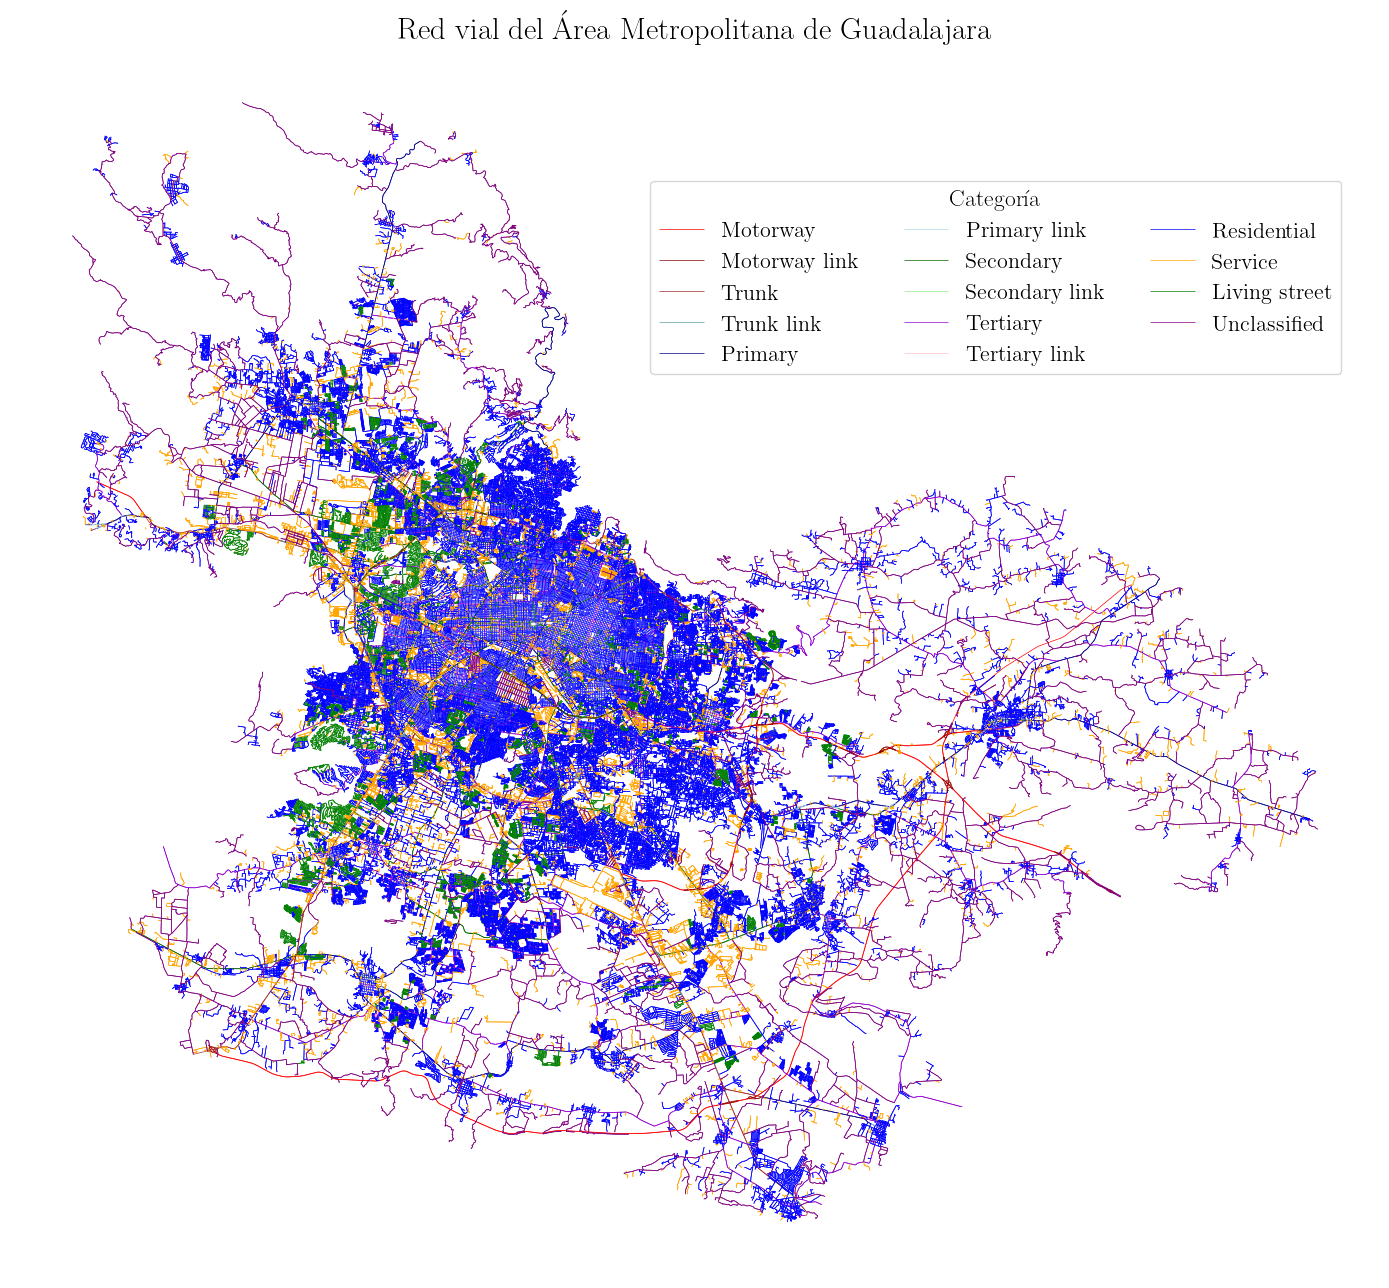

In [7]:
# Configuramos el color y el nombre de cada categoría vial
configuracion_tipos = {
    "motorway": {"color": "red", "nombre": "Motorway"},
    "motorway_link": {"color": "darkred", "nombre": "Motorway link"},
    "trunk": {"color": "brown", "nombre": "Trunk"},
    "trunk_link": {"color": "cadetblue", "nombre": "Trunk link"},
    "primary": {"color": "darkblue", "nombre": "Primary"},
    "primary_link": {"color": "lightblue", "nombre": "Primary link"},
    "secondary": {"color": "darkgreen", "nombre": "Secondary"},
    "secondary_link": {"color": "lightgreen", "nombre": "Secondary link"},
    "tertiary": {"color": "darkviolet", "nombre": "Tertiary"},
    "tertiary_link": {"color": "pink", "nombre": "Tertiary link"},
    "residential": {"color": "blue", "nombre": "Residential"},
    "service": {"color": "orange", "nombre": "Service"},
    "living_street": {"color": "green", "nombre": "Living street"},
    "unclassified": {"color": "purple", "nombre": "Unclassified"}
}

fig, ax = plt.subplots(figsize=(14, 14))
for categoria, config in configuracion_tipos.items():
    capa = red_vial_completa[red_vial_completa["categoria"] == categoria]
    if capa.empty:
        continue
    capa.plot(ax=ax, color=config["color"], linewidth=0.5, label=config["nombre"])

ax.set_title("Red vial del Área Metropolitana de Guadalajara", fontsize=22)
ax.set_axis_off()
ax.legend(title="Categoría", loc="upper right", bbox_to_anchor=(0.98, 0.9), ncol=3, fontsize=16, title_fontsize=17, frameon=True)
plt.tight_layout()
plt.show()